## **1. Definition**
- This dataset contains information about the passengers of the RMS Titanic, which famously sank in 1912. Each row in the dataset represents a single passenger, and the columns contain various pieces of information about them, such as:
  - **PassengerId:** A unique identifier for each passenger.
  - **Survived:** Whether the passenger survived the sinking (this will be the main target variable to focusing on).
  - **Pclass:** The passenger's ticket class (1st, 2nd and 3rd class).
  - **Name:** The passenger's name.
  - **Sex:** The passenger's gender.
  - **Age:** The passenger's age.
  - **SibSp:** Number of siblings/spouses aboard.
  - **Parch:** Number of parents/children aboard.
  - **Ticket:** Ticket number.
  - **Fare:** The fare paid for the ticket.
  - **Cabin:** The cabin number.
  - **Embarked:** The port where the passenger embarked.
- The utmost reason to analyze this dataset, especially in the context of data science and machine learning, is typically to build a model that can predict whether a passenger survived the sinking based on the information available about them.

## **2. Import libraries**

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib

## **3. Load the dataset**

In [117]:
train_df = pd.read_csv('data/train.csv' , index_col="PassengerId")
test_df = pd.read_csv('data/test.csv' , index_col="PassengerId")

In [118]:
train_df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [119]:
test_df.columns

Index(['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Cabin', 'Embarked'],
      dtype='object')

In [120]:
train_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### **3.1. Features Classification: Categorical and Numerical**
- This will help to decide which plot to use for visualization.
#### **Which are the categorical features?**
- Data that represents groups, labels, or categories.
- Include: `Survived`, `Sex`, `Embarked`, `Pclass`.
#### **Which are the numerical features?**
- Data that represents measurable quantities.
- Include: `Age`, `Fare`, `SibSp`, `Parch`.

In [121]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [122]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     object 
 9   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 35.9+ KB


In [123]:
features = ["Pclass", "SibSp", "Parch"]
def convert_cat(df, features):
  for feature in features:
    df[feature] = df[feature].astype('category')
  return df

train_df = convert_cat(train_df, features)
test_df = convert_cat(test_df, features)

In [124]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    int64   
 1   Pclass    891 non-null    category
 2   Name      891 non-null    object  
 3   Sex       891 non-null    object  
 4   Age       714 non-null    float64 
 5   SibSp     891 non-null    category
 6   Parch     891 non-null    category
 7   Ticket    891 non-null    object  
 8   Fare      891 non-null    float64 
 9   Cabin     204 non-null    object  
 10  Embarked  889 non-null    object  
dtypes: category(3), float64(2), int64(1), object(5)
memory usage: 66.1+ KB


### **3.1.1. Distribution of Categorical features**

In [125]:
train_df.describe(include='category')

,Pclass,SibSp,Parch
count,891,891,891
unique,3,7,7
top,3,0,0
freq,491,608,678


### **3.1.2. Distribution of Numerical features**

In [126]:
train_df.describe()

,Survived,Age,Fare
count,891.000000,714.000000,891.000000
mean,0.383838,29.699118,32.204208
std,0.486592,14.526497,49.693429
min,0.000000,0.420000,0.000000
25%,0.000000,20.125000,7.910400
50%,0.000000,28.000000,14.454200
75%,1.000000,38.000000,31.000000
max,1.000000,80.000000,512.329200


## **4. Exploratory Data Analysis (EDA)**
### **4.1. Collerating categorical features**
- Catergorical: `Survived`, `Pclass`, `Sex`, `SibSp`,
       `Parch`, `Embarked`
### **Target variable: `Survived`**

In [127]:
train_df['Survived'].value_counts().to_frame()

,count
Survived,
0,549
1,342


In [128]:
train_df['Survived'].value_counts(normalize=True).to_frame()

,proportion
Survived,
0,0.616162
1,0.383838


Conclude that only 38% of the passengers survived. The data suffered from data imbalanced but not too severe to tackle the imbalance with data sampling.

### **Remaining features**

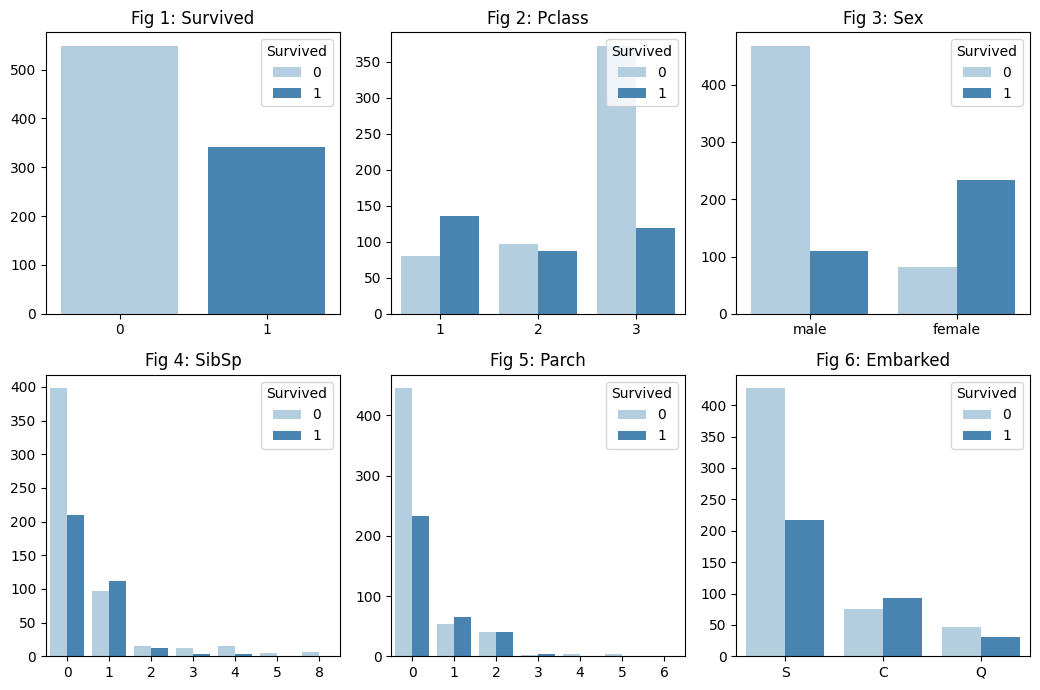

In [129]:
cols = ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']

n_rows = 2
n_cols = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3.5, n_rows*3.5))

for r in range(n_rows):
  for c in range(0, n_cols):
    i = r*n_cols + c
    if i < len(cols):
      ax = axes[r][c]
      sns.countplot(x=cols[i], hue='Survived', data=train_df, ax=ax, palette='Blues')
      ax.set_title(f'Fig {i+1}: {cols[i]}')
      ax.legend(title='Survived', loc='upper right')
      ax.set_xlabel('')
      ax.set_ylabel('')

plt.tight_layout()

#### **Observation:**
- **Survival rate:**
  - Fig 2: Survival rate of the 1st class is the highest.
  - Fig 3: Female had significant higher survival rate than male.  
  - Fig 4 and 5: Passengers who were with 1 or 2 family members had higher chance than going alone.
  - Fig 6: Embarked on Southampton had better chance of surviving but also had the highest rate of not survived.

### **4.2. EDA for Numerical features**
- Numerical features: `Age`, `Fare`.

#### **Age**

In [130]:
train_df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: xlabel='Age', ylabel='Count'>

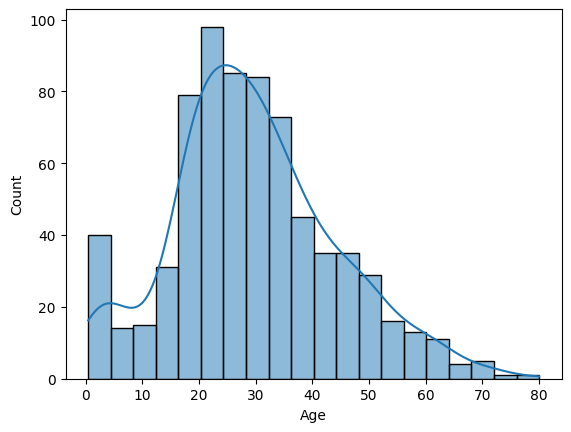

In [131]:
sns.histplot(x='Age', data=train_df, kde=True)

<Axes: xlabel='Age', ylabel='Count'>

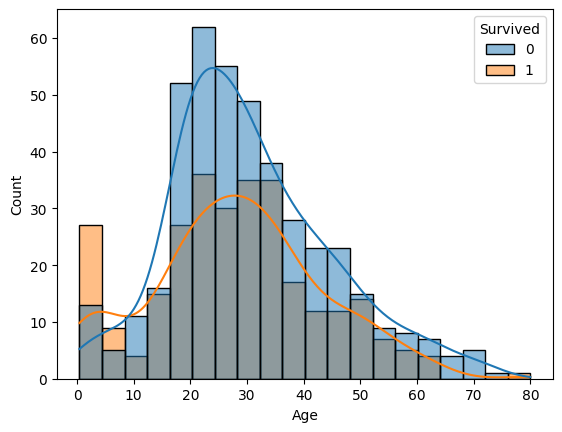

In [132]:
sns.histplot(data=train_df, kde=True, x='Age', hue='Survived')

- The majority of passengers were around 18 to 35 years old.
- Children had higher chance of surviving due to the "women and children first" protocol.

#### **Fare**

In [133]:
train_df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: xlabel='Fare', ylabel='Count'>

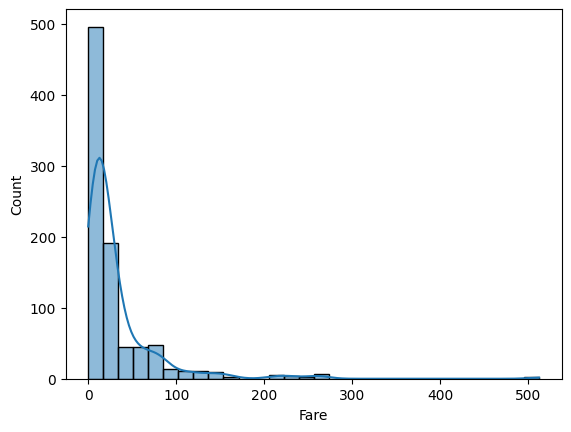

In [134]:
sns.histplot(x='Fare', data=train_df, bins = 30, kde=True)

<Axes: xlabel='Fare', ylabel='Count'>

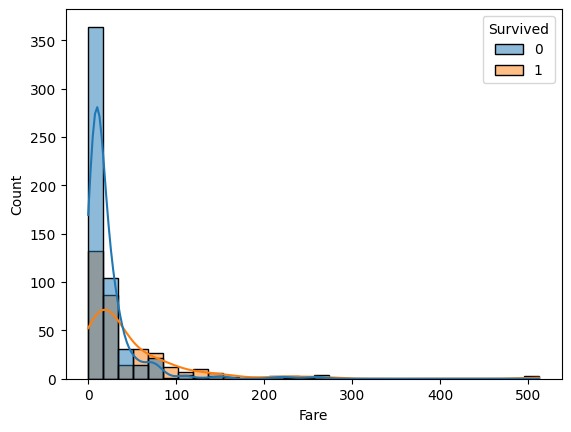

In [135]:
sns.histplot(data=train_df, kde=True, x='Fare', bins = 30, hue='Survived')

In [136]:
pd.qcut(train_df['Fare'], 4)

PassengerId
1       (-0.001, 7.91]
2      (31.0, 512.329]
3       (7.91, 14.454]
4      (31.0, 512.329]
5       (7.91, 14.454]
            ...       
887     (7.91, 14.454]
888     (14.454, 31.0]
889     (14.454, 31.0]
890     (14.454, 31.0]
891     (-0.001, 7.91]
Name: Fare, Length: 891, dtype: category
Categories (4, interval[float64, right]): [(-0.001, 7.91] < (7.91, 14.454] < (14.454, 31.0] < (31.0, 512.329]]

In [137]:
train_df['Fare_Category'] = pd.qcut(train_df['Fare'], 4)
display(train_df[['Fare', 'Fare_Category']].head())

,Fare,Fare_Category
PassengerId,,
1,7.2500,"(-0.001, 7.91]"
2,71.2833,"(31.0, 512.329]"
3,7.9250,"(7.91, 14.454]"
4,53.1000,"(31.0, 512.329]"
5,8.0500,"(7.91, 14.454]"


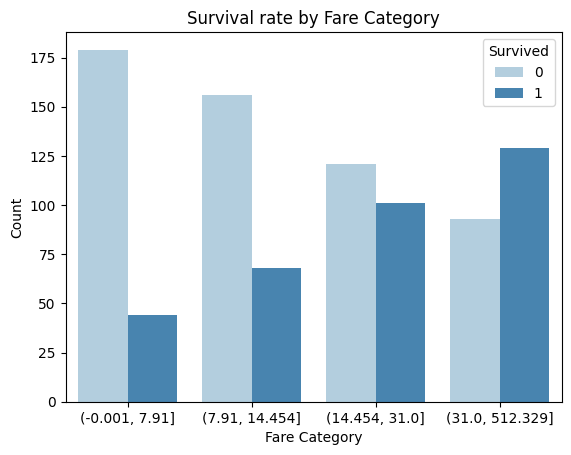

In [138]:
sns.countplot(x='Fare_Category', hue='Survived', data=train_df, palette='Blues')
plt.title('Survival rate by Fare Category')
plt.xlabel('Fare Category')
plt.ylabel('Count')
plt.show()

- Distribution of fare:
  - A large number of passengers paid a lower fare while there are fewer passengers who paid increasingly higher fares. This indicates the fare distribution is skewed.
  - The distribution is skewed to the left side with 75% of the fare paid under `31$` with the max paid of `512$`.
- Relationship with Survival:
  - It became clear that passengers who paid higher fares had more chance of surviving. This suggests a strong positive correlation between the fare paid and the chance of survival.

### **4.3. Handling missing values**

In [139]:
train_df.dropna(subset=['Age'], inplace=True)
test_df.dropna(subset=['Age'], inplace=True)

mode_embarked = train_df['Embarked'].mode()[0]
train_df['Embarked'] = train_df['Embarked'].fillna(mode_embarked)
test_df['Embarked'] = test_df['Embarked'].fillna(mode_embarked)

train_df['Cabin'] = train_df['Cabin'].fillna('Missing')
test_df['Cabin'] = test_df['Cabin'].fillna('Missing')

print("Missing values in Age after handling (Train):", train_df['Age'].isnull().sum())
print("Missing values in Age after handling (Test):", test_df['Age'].isnull().sum())
print("Missing values in Embarked after handling (Train):", train_df['Embarked'].isnull().sum())
print("Missing values in Embarked after handling (Test):", test_df['Embarked'].isnull().sum())
print("Missing values in Cabin after handling (Train):", train_df['Cabin'].isnull().sum())
print("Missing values in Cabin after handling (Test):", test_df['Cabin'].isnull().sum())

Missing values in Age after handling (Train): 0
Missing values in Age after handling (Test): 0
Missing values in Embarked after handling (Train): 0
Missing values in Embarked after handling (Test): 0
Missing values in Cabin after handling (Train): 0
Missing values in Cabin after handling (Test): 0


- **Embarked:** only had 2 missing values. In such case, it's preferable to fill the missing values with reasonable estimate information.
- **Age:** had a significantly large number of missing values (177 in the original training data). Dropping rows will keep the process simple.
- **Cabin:** this column had a very large number of missing values up to 687 (about 77.10%), we would removed a significant portion of the dataset if dropped, which is not ideal for analysis. Instead filling will allow us to keep all the rows and potentially explore.

## **Long**
**Mục tiêu:**
- Chuẩn bị dữ liệu & xử lý đặc trưng
- Huấn luyện mô hình baseline: 
    + Linear Algorithms: Logistic Regression 
    + Nonlinear Algorithms: Classi cation and Regression Trees (CART)

In [140]:
# hiển thị đồ thị inline
%matplotlib inline
print("Ready")

Ready


In [141]:
# Load dữ liệu (place train.csv vào cùng thư mục notebook)
import os
print("Working dir:", os.getcwd())

try:
    train = pd.read_csv("data/train.csv")
    display(train.head())
    print("\nMissing summary:")
    print(train.isnull().sum())
except FileNotFoundError:
    print("Không tìm thấy file train.csv.")

Working dir: e:\KHDL\Khai phá dữ liệu\challenge_1_v2\sgu25-khaiphadulieu


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Missing summary:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### 1. Khảo sát nhanh (EDA)
Quan sát các biến, phân phối và mối quan hệ với `Survived`.

Shape: (891, 12)

Các giá trị duy nhất mỗi cột:
PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64


Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


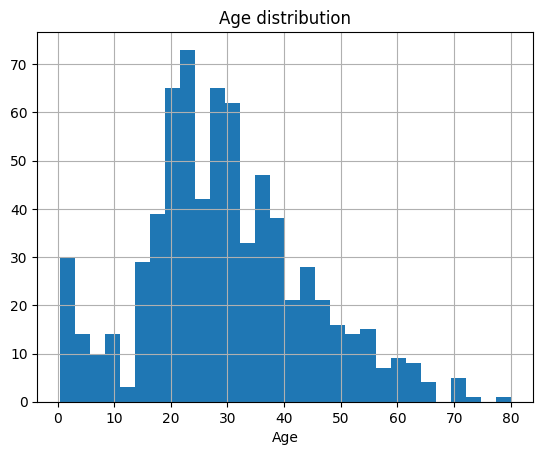

In [142]:
# Nếu train đã được load, thực hiện EDA cơ bản
if 'train' in globals():
    print('Shape:', train.shape)
    print('\nCác giá trị duy nhất mỗi cột:')
    print(train.nunique())
    # Tỷ lệ sống sót theo giới tính và hạng
    display(pd.crosstab(train['Sex'], train['Survived'], normalize='index'))
    display(pd.crosstab(train['Pclass'], train['Survived'], normalize='index'))
    # Biểu đồ tuổi
    train['Age'].hist(bins=30)
    plt.title('Age distribution')
    plt.xlabel('Age')
    plt.show()

### 2. Xử lý đặc trưng (Feature Engineering)
- Điền missing
- Tạo biến mới: `FamilySize`, `IsAlone`, `Title` (tách từ `Name`)
- Loại bỏ các cột ít hữu ích trực tiếp như `Ticket`, `Cabin` (có thể dùng sau này)

In [143]:
if 'train' in globals():
    df = train.copy()
    # Tạo FamilySize và IsAlone
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # Extract Title từ Name
    df['Title'] = df['Name'].str.extract(',\s*([^\.]+)\.', expand=False)
    # Gom nhóm các title ít gặp
    df['Title'] = df['Title'].replace(['Mlle','Ms'],'Miss')
    df['Title'] = df['Title'].replace('Mme','Mrs')
    rare_titles = df['Title'].value_counts()[df['Title'].value_counts() < 10].index
    df['Title'] = df['Title'].replace(list(rare_titles), 'Rare')

    display(df[['Name','Title']].head())
    display(df[['FamilySize','IsAlone']].head())

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Dell 7480\AppData\Local\Temp\ipykernel_1508\713177670.py:8: SyntaxWarning: invalid escape sequence '\s'
  df['Title'] = df['Name'].str.extract(',\s*([^\.]+)\.', expand=False)


,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr


,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


### 3. Chọn features cho baseline
Chúng ta dùng các feature đơn giản: `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`, `FamilySize`, `IsAlone`, `Title`.

In [144]:
if 'train' in globals():
    features = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked','FamilySize','IsAlone','Title']
    X = df[features].copy()
    y = df['Survived'].copy()
    X.head()

### 4. Pipeline tiền xử lý
- Impute numerical bằng median
- Impute categorical bằng mode
- One-hot encode categorical
- Standardize numeric trước khi đưa vào Logistic Regression

In [145]:
from sklearn.pipeline import make_pipeline

if 'train' in globals():
    numeric_features = ['Age','SibSp','Parch','Fare','FamilySize']
    categorical_features = ['Pclass','Sex','Embarked','IsAlone','Title']

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

In [146]:
if 'train' in globals():
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    # Build pipeline with logistic regression
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', LogisticRegression(max_iter=1000))])
    clf.fit(X_train, y_train)
    print("Done training baseline Logistic Regression")

Done training baseline Logistic Regression


Accuracy: 0.8547486033519553

Classification report:
               precision    recall  f1-score   support

           0       0.86      0.91      0.88       110
           1       0.84      0.77      0.80        69

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179


Confusion matrix:
 [[100  10]
 [ 16  53]]

ROC AUC: 0.8790513833992095


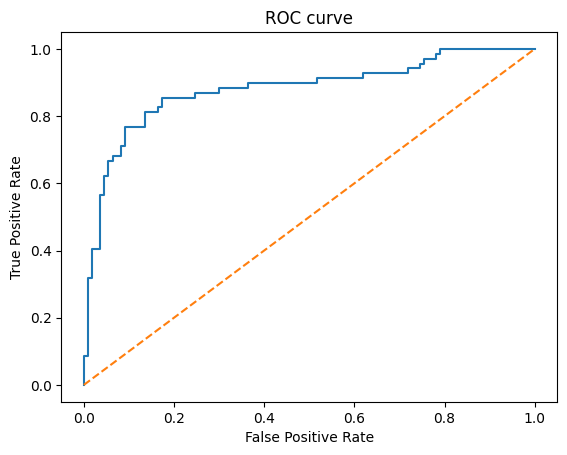

In [147]:
if 'train' in globals():
    y_pred = clf.predict(X_val)
    y_proba = clf.predict_proba(X_val)[:,1]
    print("Accuracy:", accuracy_score(y_val, y_pred))
    print("\nClassification report:\n", classification_report(y_val, y_pred))
    print("\nConfusion matrix:\n", confusion_matrix(y_val, y_pred))
    print("\nROC AUC:", roc_auc_score(y_val, y_proba))

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1],'--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curve')
    plt.show()

### 5. Cross-validation (tùy chọn)
Để kiểm tra ổn định, ta có thể chạy cross-val trên pipeline.

In [148]:
if 'train' in globals():
    scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
    print("CV accuracy scores:", scores)
    print("Mean CV accuracy:", scores.mean())

CV accuracy scores: [0.82122905 0.81460674 0.80337079 0.80337079 0.87078652]
Mean CV accuracy: 0.8226727763480008


### 6. Lưu model
Lưu pipeline đã huấn luyện để dùng lại.

In [149]:
if 'train' in globals():
    joblib.dump(clf, 'titanic_logreg_baseline.joblib')
    print("Saved model to titanic_logreg_baseline.joblib")

Saved model to titanic_logreg_baseline.joblib


### 7. Classification and Regression Trees (CART)

In [150]:
# Xác định biến
numeric_features = ['Age','SibSp','Parch','Fare','FamilySize']
categorical_features = ['Pclass','Sex','Embarked','IsAlone','Title']

numeric_transformer = SimpleImputer(strategy='median')
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [151]:
# CART model
cart_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

In [152]:
# Build pipeline
cart_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', cart_model)
])

# Train
cart_pipeline.fit(X_train, y_train)

# Predict
y_pred = cart_pipeline.predict(X_val)

# Lưu pipeline đã train
joblib.dump(cart_pipeline, "cart_pipeline_model.pkl")
print("Đã lưu model thành công!")

Đã lưu model thành công!


# Phuong

In [154]:
# Load dữ liệu đã xử lý ở P1
train_df, test_df = joblib.load('titanic_after_P1.pkl')

print("✅ [LOG] Đã load dữ liệu sau P1!")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'titanic_after_P1.pkl'

In [ ]:
# ===== FIX FARE_CATEGORY CHO TEST  =====

import pandas as pd

# Bins đúng chuẩn qcut của Híu
fare_bins = train_df['Fare'].quantile([0, 0.25, 0.5, 0.75, 1]).values

# Áp dụng bins này cho train và test
train_df['Fare_Category'] = pd.cut(train_df['Fare'], bins=fare_bins, include_lowest=True)
test_df['Fare_Category']  = pd.cut(test_df['Fare'], bins=fare_bins, include_lowest=True)

print("✅ Đã tái tạo Fare_Category cho TRAIN & TEST ")


In [ ]:
# Import các class cần thiết
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Load mô hình baseline
logreg_model = joblib.load('/content/drive/MyDrive/Colab Notebooks/sgu25-khaiphadulieu/challenge_1_titanic/titanic_logreg_baseline.joblib')
cart_model = joblib.load('/content/drive/MyDrive/sgu25-khaiphadulieu/challenge_1_titanic/cart_pipeline_model.pkl')

print("✅ [LOG] Đã load 2 mô hình baseline thành công!")


In [ ]:
import os
from datetime import datetime

# Tạo thư mục logs nếu chưa có
if not os.path.exists("html_logs"):
    os.makedirs("html_logs")

def save_html_log(title, content):
    """
    Tạo file HTML chứa toàn bộ nội dung log của cell vừa chạy.
    title: tên file (không dấu, không khoảng trắng)
    content: nội dung HTML/text để ghi vào file
    """
    filename = f"html_logs/{title}.html"
    html_template = f"""
    <html>
    <head>
        <meta charset="UTF-8">
        <title>{title}</title>
        <style>
            body {{ font-family: Arial; padding:20px; }}
            pre {{ background:#f4f4f4; padding:10px; border-radius:8px; }}
        </style>
    </head>
    <body>
        <h2>{title}</h2>
        <pre>{content}</pre>
    </body>
    </html>
    """
    with open(filename, "w", encoding="utf-8") as f:
        f.write(html_template)

    print("✅ Đã lưu log HTML:", filename)


### 1. Huấn luyện cải thiện tham số

In [ ]:
#tạo lại preprocessor đúng với dataset
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Fare_Category']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [ ]:
#tạo lại preprocessor đúng với dataset
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Fare_Category']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression

X = train_df[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked','Fare_Category']]
y = train_df['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

log_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

param_grid_log = {
    'model__C': [0.1, 1.0, 10.0],
}

log_grid = GridSearchCV(log_pipeline, param_grid_log, cv=5, scoring='accuracy')
log_grid.fit(X_train, y_train)

best_log_model = log_grid.best_estimator_
joblib.dump(best_log_model, "logreg_tuned_pipeline.joblib")

print("✅ DONE!")
print("Best params:", log_grid.best_params_)


1.1. Tuning Logistic Regression
* Logistic Regression baseline chỉ chạy với cấu hình mặc định → chưa tối ưu.

* Ta dùng GridSearchCV (5-fold cross-validation) để tìm hệ số C tốt nhất.

* Preprocessor xử lý numeric + categorical trước khi model fit.



In [ ]:

# ==== CELL DEFINITIONS ====

# 1. Numeric theo dataset P1
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']

# 2. Categorical theo dataset P1
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Fare_Category']

# 3. Features dùng cho training (X)
feature_cols = numeric_features + categorical_features

print("✅ feature_cols đã được định nghĩa lại cho P1 dataset:")
print(feature_cols)

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression

log_text = ">>> Tuning Logistic Regression\n\n"

# 1. Lấy X, y từ dữ liệu bước EDA
X = train_df[feature_cols]
y = train_df['Survived']

log_text += f"Using features: {feature_cols}\n\n"

# 2. Split thành train/val để đánh giá tuning
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

log_text += f"X_train shape: {X_train.shape}\n"
log_text += f"X_val shape: {X_val.shape}\n\n"

# 3. Pipeline Logistic Regression + preprocessor đã chuẩn hóa
log_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

# 4. Bộ tham số cần tuning
param_grid_log = {
    'model__C': [0.1, 1, 10],
}

# 5. GridSearchCV dùng 5-fold CV
grid = GridSearchCV(log_pipeline, param_grid_log, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

# 6. Lưu mô hình tốt nhất
best_log_model = grid.best_estimator_
joblib.dump(best_log_model, "logreg_tuned_pipeline.joblib")

log_text += f"Best params: {grid.best_params_}\n"
log_text += f"CV score: {grid.best_score_:.4f}\n"
log_text += "Saved: logreg_tuned_pipeline.joblib\n"

# 7. Lưu log HTML
title = datetime.now().strftime("%Y-%m-%d") + "_Tuning_LogisticRegression"
save_html_log(title, log_text)

print("✅ Logistic Regression tuning DONE")


1.2. Tuning Decision Tree
* Tối ưu mô hình Decision Tree để so sánh với Logistic Regression

In [ ]:

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier
from datetime import datetime

dt_text = ">>> CELL 4 — Tuning Decision Tree\n\n"

# 1) Lấy X, y từ dữ liệu sau P1
X = train_df[feature_cols]
y = train_df["Survived"]

dt_text += f"Số lượng feature: {len(feature_cols)}\n"
dt_text += f"Features dùng để train: {feature_cols}\n\n"

# 2) Tách train/val để đánh giá tuning
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dt_text += f"X_train shape: {X_train.shape}\n"
dt_text += f"X_val shape: {X_val.shape}\n\n"

# 3) Pipeline Decision Tree
pipeline_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier())
])

# 4) GridSearch parameters
dt_params = {
    'model__max_depth': [3, 5, 7, None],
    'model__min_samples_split': [2, 5, 10]
}

# 5) GridSearchCV
dt_grid = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=dt_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

# 6) Lưu mô hình tốt nhất
best_dt_model = dt_grid.best_estimator_
joblib.dump(best_dt_model, "dt_tuned_pipeline.joblib")

dt_text += f"Best params: {dt_grid.best_params_}\n"
dt_text += f"Best CV score: {dt_grid.best_score_:.4f}\n"
dt_text += "Đã lưu mô hình: dt_tuned_pipeline.joblib\n"

# 7) Lưu HTML log
title = datetime.now().strftime("%Y-%m-%d") + "_Tuning_DecisionTree"
save_html_log(title, dt_text)

print("✅ CELL 4 DONE — Decision Tree tuning hoàn tất.")



### 2. KẾT HỢP MÔ HÌNH

#### 2.1. Ensemble Bagging / RF / AdaBoost

* Huấn luyện 3 mô hình ensemble cổ điển để đánh giá mức cải thiện so với Logistic Regression & Decision Tree.

In [ ]:

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import cross_val_score
from datetime import datetime

ens_text = ">>> Ensemble Models\n\n"

# 1) Danh sách ensemble
models = {
    "Bagging": BaggingClassifier(),
    "RandomForest": RandomForestClassifier(n_estimators=100),
    "AdaBoost": AdaBoostClassifier(n_estimators=100)
}

# 2) Train + Cross-Validation
for name, clf in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', clf)
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')

    ens_text += f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})\n"

    pipe.fit(X_train, y_train)
    joblib.dump(pipe, f"{name.lower()}_pipeline.joblib")
    ens_text += f"Đã lưu mô hình: {name.lower()}_pipeline.joblib\n\n"

# 3) Lưu HTML log
title = datetime.now().strftime("%Y-%m-%d") + "_Ensemble_Models"
save_html_log(title, ens_text)

print("✅ CELL 5 DONE — Ensemble models hoàn tất.")



NameError: name 'save_html_log' is not defined

#### 2.2. Voting Ensemble

In [ ]:

from sklearn.ensemble import VotingClassifier
from datetime import datetime

vote_text = ">>> Voting Ensemble\n\n"

voting_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000)),
            ('dt', DecisionTreeClassifier(max_depth=5)),
            ('rf', RandomForestClassifier(n_estimators=100))
        ],
        voting='soft'
    ))
])

voting_model.fit(X_train, y_train)
joblib.dump(voting_model, "voting_pipeline.joblib")

vote_text += "Voting Ensemble đã train xong.\n"
vote_text += "Đã lưu mô hình: voting_pipeline.joblib\n"

title = datetime.now().strftime("%Y-%m-%d") + "_Voting_Ensemble"
save_html_log(title, vote_text)

print("✅  Voting Ensemble hoàn tất.")



### 3. ĐÁNH GIÁ & LƯU CUỐI

* Đánh giá toàn bộ mô hình đã train trên tập validation để so sánh performance

In [ ]:
# ===================== =Evaluation  =====================
import pandas as pd
from sklearn.metrics import accuracy_score
from datetime import datetime

eval_text = ">>> CELL 7 — Evaluation Report\n\n"
results = []

model_files = {
    "Logistic Regression (tuned)": "logreg_tuned_pipeline.joblib",
    "Decision Tree (tuned)": "dt_tuned_pipeline.joblib",
    "Bagging": "bagging_pipeline.joblib",
    "Random Forest": "randomforest_pipeline.joblib",
    "AdaBoost": "adaboost_pipeline.joblib",
    "Voting Ensemble": "voting_pipeline.joblib"
}

for name, file in model_files.items():
    model = joblib.load(file)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    results.append([name, acc])

df_eval = pd.DataFrame(results, columns=["Model", "Accuracy"])
df_eval = df_eval.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

eval_text += df_eval.to_string(index=False) + "\n\n"
eval_text += f"Best model: {df_eval.iloc[0]['Model']}"

title = datetime.now().strftime("%Y-%m-%d") + "_Evaluation"
save_html_log(title, eval_text)

max_accuracy = df_eval['Accuracy'].max()

def highlight_best_row(row):
    if row.Accuracy == max_accuracy:
        return ['font-weight: bold;'] * len(row)
    else:
        return ['font-weight: normal;'] * len(row)

table_styles = [
    {
        'selector': 'th',
        'props': [
            ('background-color', '#0d47a1'),
            ('color', 'white'),
            ('text-align', 'center'),
            ('font-size', '11pt')
        ]
    },
    {
        'selector': 'td',
        'props': [
            ('background-color', '#FFFFFF'),
            ('color', 'black'),
            ('padding', '5px')
        ]
    },
    {
        'selector': 'td:nth-child(1)',
        'props': [('text-align', 'left')]
    },
    {
        'selector': 'td:nth-child(2)',
        'props': [('text-align', 'center')]
    }
]

styled_df = (
    df_eval.style
    .set_table_styles(table_styles)
    .apply(highlight_best_row, axis=1)
    .format({'Accuracy': '{:.6f}'})
    .hide()
)

styled_df




### 4. Huấn luyện model cuối cùng và lưu

* Train lại mô hình tốt nhất trên toàn bộ tập train_df và lưu thành mô hình cuối.

In [ ]:
# === Detailed evaluation for the chosen best model (Classification report + Confusion matrix) ===
import joblib
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.validation import check_is_fitted
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime

# Lấy tên và đường dẫn model tốt nhất từ df_eval và model_files
best_model_name = df_eval.iloc[0]['Model']
best_model_path = model_files[best_model_name]
print(f"Selected best model from df_eval: {best_model_name}")
print(f"Loading model file: {best_model_path}")

# Load model
best_model = joblib.load(best_model_path)

# Nếu model chưa được fit (không fitted), fit tạm trên X_train để có thể đánh giá trên X_val
try:
    # check_is_fitted sẽ raise nếu chưa fit
    check_is_fitted(best_model)
    fitted_ok = True
except Exception:
    fitted_ok = False

if not fitted_ok:
    print("Model chưa được fit. Sẽ huấn luyện tạm trên X_train để có thể đánh giá trên X_val.")
    best_model.fit(X_train, y_train)
else:
    print("Model đã fit — sẵn sàng predict trên X_val.")

# Predict trên validation set
y_val_pred = best_model.predict(X_val)

# Accuracy
acc = accuracy_score(y_val, y_val_pred)
print(f"\n✅ Accuracy trên X_val: {acc:.4f}\n")

# Classification report (với tên lớp rõ ràng)
target_names = ["Không sống sót", "Sống sót"]
creport = classification_report(y_val, y_val_pred, target_names=target_names)
print("📋 Classification Report:\n")
print(creport)

# Confusion matrix và heatmap
cm = confusion_matrix(y_val, y_val_pred)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.tight_layout()
plt.show()

# --- (Tùy chọn) Lưu report + hình để chèn slide ---
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
report_txt = f"classification_report_{best_model_name.replace(' ','_')}_{timestamp}.txt"
with open(report_txt, "w", encoding="utf-8") as f:
    f.write(f"Model: {best_model_name}\n")
    f.write(f"Accuracy on X_val: {acc:.4f}\n\n")
    f.write(creport)

# Lưu hình ma trận
fig_path = f"confusion_matrix_{best_model_name.replace(' ','_')}_{timestamp}.png"
plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.tight_layout()
plt.savefig(fig_path, dpi=200)
plt.close()

print(f"\n✅ Saved classification report -> {report_txt}")
print(f"✅ Saved confusion matrix image -> {fig_path}")




### 5. dự đoán trên TEST SET + lưu submission.csv

In [ ]:
from datetime import datetime
from IPython.display import display, HTML
import pandas as pd

# Nhật ký text
test_text = ">>>  Prediction on Test Set\n\n"

# 1) Lấy X_test đúng cột
X_test = test_df[feature_cols]

test_text += f"Số lượng mẫu test: {len(X_test)}\n"
test_text += f"Feature columns dùng cho test: {feature_cols}\n\n"

# 2) Load final model đã train full data ở Cell 8
final_model = joblib.load("titanic_final_model.joblib")
test_text += "Final model loaded: titanic_final_model.joblib\n\n"

# 3) Predict
test_pred = final_model.predict(X_test)
test_text += "Dự đoán test thành công.\n"

# 4) Tạo dataframe kết quả tạm (không phải submission)
test_result = pd.DataFrame({
    "PassengerId": test_df.index,
    "Predicted_Survived": test_pred
})

# 5) Lưu kết quả dự đoán ra file CSV nội bộ
test_result.to_csv("test_predictions.csv", index=False)
test_text += "Đã lưu file test_predictions.csv\n\n"

# 6) Lưu HTML log
title = datetime.now().strftime("%Y-%m-%d") + "_Test_Prediction"
save_html_log(title, test_text)

display(HTML("<h3 style='color: green;'>✅ CELL 9 DONE — Test prediction hoàn tất.</h3>"))
display(HTML("<h4>Kết quả dự đoán (5 hàng đầu tiên):</h4>"))

# --- Tạo kiểu cho bảng test_result.head() ---
table_styles = [
    {
        'selector': 'th',
        'props': [
            ('background-color', '#0d47a1'),
            ('color', 'white'),
            ('text-align', 'center'),
            ('font-size', '11pt')
        ]
    },
    {
        'selector': 'td',
        'props': [
            ('background-color', '#f4f6f8'),
            ('color', 'black'),
            ('padding', '5px')
        ]
    },
    {
        'selector': 'td:nth-child(1)',
        'props': [('text-align', 'center'), ('font-weight', 'bold')]
    },
    {
        'selector': 'td:nth-child(2)',
        'props': [('text-align', 'center')]
    }
]

styled_test_head = (
    test_result.head().style
    .set_table_styles(table_styles)
    .hide()
)

display(styled_test_head)


### Kết Luận
* Dựa trên kết quả đánh giá mô hình ở bước validation, Voting là mô hình đạt hiệu suất cao nhất với accuracy = 0.7902, vượt qua các mô hình khác về hiệu suất

* Điều này cho thấy Voting phù hợp với cấu trúc dữ liệu của Titanic, khi nó có khả năng kết hợp nhiều weak learners để bắt tốt các quan hệ phi tuyến nhưng vẫn tránh overfitting.

* Sau khi chọn Voting làm mô hình cuối, tôi đã huấn luyện lại mô hình trên toàn bộ dữ liệu train nhằm tận dụng toàn bộ thông tin, rồi dùng mô hình này để dự đoán trên tập test, kết quả được lưu trong file